# Building a Basic CNN: The MNIST Dataset

In this notebook, we will build a simple CNN-based architecture to classify the 10 digits (0-9) of the MNIST dataset. The objective of this notebook is to become familiar with the process of building CNNs in Keras.

We will go through the following steps:
1. Importing libraries and the dataset
2. Data preparation: Train-test split, specifying the shape of the input data etc.
3. Building and understanding the CNN architecture
4. Fitting and evaluating the model

Let's dive in.

## 1. Importing Libraries and the Dataset

Let's load the required libraries. From Keras, we need to import two main components:
1. `Sequential` from `keras.models`: `Sequential` is the keras abstraction for creating models with a stack of layers (MLP has multiple hidden layers, CNNs have convolutional layers, etc.).
2. Various types of layers from `keras.layers`: These layers are added (one after the other) to the `Sequential` model

The keras `backend` is needed for keras to know that you are using tensorflow (not Theano) at the backend (the backend is <a href="https://keras.io/backend/">specified in a JSON file</a>).


In [1]:
import numpy as np
import random

import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

In [133]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [134]:
X_train.shape

(60000, 28, 28)

In [135]:
y_train.shape

(60000,)

In [4]:
x_test = X_test.copy()

In [ ]:
img_rows = 28
img_cols = 28

In [136]:
X_train = np.array(X_train).reshape(-1, 28, 28, 1)
X_test = np.array(X_test).reshape(-1, img_rows, img_cols, 1)

In [6]:
x_train = X_train.copy()

In [7]:
img_rows = 28
img_cols = 28

In [8]:
x_train = x_train.reshape(x_train.shape[0], img_rows, img_cols, 1)
x_test = x_test.reshape(x_test.shape[0], img_rows, img_cols, 1)
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [98]:
# X_train = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1)
# X_test = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)
# print(X_train.shape)
# print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [9]:
# X_test = np.array(X_test).reshape(X_test.shape[0], 28, 28, 1)

In [137]:
X_train.shape

(60000, 28, 28, 1)

In [138]:
y_train.shape

(60000,)

In [60]:
np.max(X_train[0])

np.uint8(255)

## Normalizing between 0-1

In [16]:
np.max(X_train / 255)

np.float64(1.0)

In [102]:
X_train = X_train / 255

In [104]:
X_train.shape

(60000, 28, 28, 1)

In [139]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)
print(y_train.shape)

(60000, 10)


In [162]:
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")

# normalise
X_train /= 255
X_test /= 255

In [163]:
from sklearn.model_selection import train_test_split

#
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, random_state=42, test_size=0.1
)

In [164]:
print(f"X{X_train.shape, X_val.shape, y_train.shape, y_val.shape}")

X((43740, 28, 28, 1), (4860, 28, 28, 1), (43740, 10), (4860, 10))


In [11]:
def func_train_test_val(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, random_state=42, test_size=0.3
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, random_state=42, test_size=0.1
    )

In [153]:
X_train.shape

(48600, 28, 28, 1)

In [154]:
y_train.shape

(48600, 10)

In [155]:
X_val.shape

(5400, 28, 28, 1)

In [156]:
X_test.shape

(10000, 28, 28, 1)

In [157]:
y_test.shape

(10000, 10)

In [142]:
# convert class labels (from digits) to one-hot encoded vectors
# y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)

In [158]:
print(y_train.shape)

(48600, 10)


In [159]:
X_train.shape

(48600, 28, 28, 1)

In [111]:
# y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [160]:
y_train[0].dtype

dtype('float64')

In [161]:
y_train.shape

(48600, 10)

In [144]:
# X_train = X_train.astype("float32")

In [145]:
# X_test = X_test.astype("float32")

In [146]:
X_train

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [147]:
y_train.shape

(54000, 10)

In [166]:
X_val.max()

np.float32(0.003921569)

In [121]:
y_val /= 255

## 3. Building the Model

Let's now build the CNN architecture. For the MNIST dataset, we do not need to build a very sophisticated CNN - a simple shallow-ish CNN would suffice.

We will build a network with:
- two convolutional layers having 32 and 64 filters respectively,
- followed by a max pooling layer,
- and then `Flatten` the output of the pooling layer to give us a long vector,
- then add a fully connected `Dense` layer with 128 neurons, and finally
- add a `softmax` layer with 10 neurons

The generic way to build a model in Keras is to instantiate a `Sequential` model and keep adding `keras.layers` to it. We will also use some dropouts.

In [167]:
model = Sequential()
model.add(tf.keras.Input(shape=(img_rows, img_cols, 1)))
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.25))
model.add(Dense(10, activation="linear", name="using_logits"))

In [168]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ using_logits (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,882 (4.58 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

## Understanding Model Summary

It is a good practice to spend some time staring at the model summary above and verify the number of parameteres, output sizes etc. Let's do some calculations to verify that we understand the model deeply enough.

- Layer-1 (Conv2D): We have used 32 kernels of size (3, 3), and each kernel has a single bias, so we have 32 x 3 x 3 (weights) + 32 (biases) = 320 parameters (all trainable). Note that the kernels have only one channel since the input images are 2D (grayscale). By default, a convolutional layer uses stride of 1 and no padding, so the output from this layer is of shape 26 x 26 x 32, as shown in the summary above (the first element `None` is for the batch size).

- Layer-2 (Conv2D): We have used 64 kernels of size (3, 3), but this time, each kernel has to convolve a tensor of size (26, 26, 32) from the previous layer. Thus, the kernels will also have 32 channels, and so the shape of each kernel is (3, 3, 32) (and we have 64 of them). So we have 64 x 3 x 3 x 32 (weights) + 64 (biases) = 18496 parameters (all trainable). The output shape is (24, 24, 64) since each kernel produces a (24, 24) feature map.

- Max pooling: The pooling layer gets the (24, 24, 64) input from the previous conv layer and produces a (12, 12, 64) output (the default pooling uses stride of 2). There are no trainable parameters in the pooling layer.

- The `Dropout` layer does not alter the output shape and has no trainable parameters.

- The `Flatten` layer simply takes in the (12, 12, 64) output from the previous layer and 'flattens' it into a vector of length 12 x 12 x 64 = 9216.

- The `Dense` layer is a plain fully connected layer with 128 neurons. It takes the 9216-dimensional output vector from the previous layer (layer l-1) as the input and has 128 x 9216 (weights) + 128 (biases) =  1179776 trainable parameters. The output of this layer is a 128-dimensional vector.

- The `Dropout` layer simply drops a few neurons.

- Finally, we have a `Dense` softmax layer with 10 neurons which takes the 128-dimensional vector from the previous layer as input. It has 128 x 10 (weights) + 10 (biases) = 1290 trainable parameters.

Thus, the total number of parameters are 1,199,882 all of which are trainable.

In [47]:
# todo tomoroow..

In [127]:
y_train = tf

(54000, 10)

In [172]:
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer="adam",
    metrics=["accuracy"],
)

In [177]:
# todo
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="loss", mode="min", patience=7, restore_best_weights=True
)

In [170]:
X_train.ndim

4

In [173]:
import tqdm

model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=12,
    verbose=1,
    validation_data=(X_val, y_val),
)

Epoch 1/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.7061 - loss: 0.9231 - val_accuracy: 0.9053 - val_loss: 0.3128
Epoch 2/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.8968 - loss: 0.3410 - val_accuracy: 0.9315 - val_loss: 0.2324
Epoch 3/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9144 - loss: 0.2817 - val_accuracy: 0.9389 - val_loss: 0.1998
Epoch 4/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9244 - loss: 0.2473 - val_accuracy: 0.9449 - val_loss: 0.1745
Epoch 5/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.9322 - loss: 0.2233 - val_accuracy: 0.9523 - val_loss: 0.1517
Epoch 6/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9370 - loss: 0.2068 - val_accuracy: 0.9562 - val_loss: 0.1413
Epoch 7/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9399 - loss: 0.1983 - val_accuracy: 0.9570 - val_loss: 0.1321
Epoch 8/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9434 - loss: 0.1879 - 

In [175]:
history = model.history.history

In [176]:
pd.DataFrame(history)

,accuracy,loss,val_accuracy,val_loss
0,0.706104,0.923110,0.905350,0.312814
1,0.896822,0.341009,0.931481,0.232412
2,0.914358,0.281746,0.938889,0.199784
3,0.924417,0.247282,0.944856,0.174456
4,0.932213,0.223289,0.952263,0.151728
5,0.937037,0.206813,0.956173,0.141272
6,0.939918,0.198263,0.956996,0.132137
7,0.943439,0.187892,0.958230,0.131453
8,0.944559,0.178851,0.963580,0.120798
9,0.947165,0.170174,0.961111,0.123370


In [180]:
predictions = model.predict(X_test)  # todo

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [199]:
history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


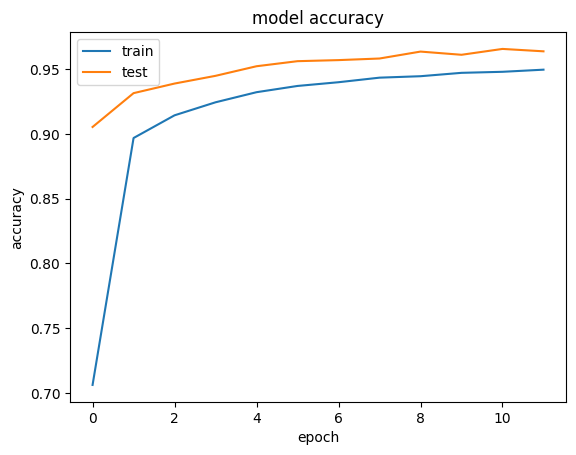

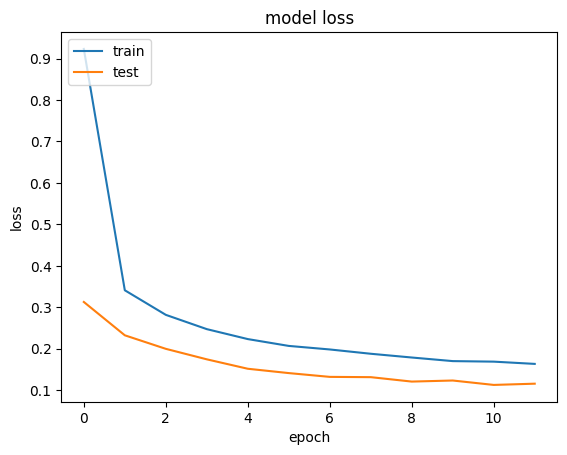

In [202]:
# list all data in history
import matplotlib.pyplot as plt

print(history.keys())
# summarize history for accuracy
plt.plot(history["accuracy"])
plt.plot(history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="upper left")
plt.show()
# summarize history for loss
plt.plot(history["loss"])
plt.plot(history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "test"], loc="upper left")
plt.show()

In [181]:
logits = predictions.copy()

In [182]:
y_pred = np.argmax(logits, axis=1)

In [185]:
y_train.shape

(43740, 10)

In [186]:
y_test.shape

(10000, 10)

In [187]:
y_true = np.argmax(y_test, axis=1)

In [188]:
incorrect_predictions = y_pred != y_true

TypeError: device_v2() missing 1 required positional argument: 'device_name'

In [189]:
error_rate = np.mean(incorrect_predictions)

In [190]:
error_rate

np.float64(0.032)

In [192]:
print(f"Prediction Error Rate: {error_rate * 100:.2f}%")
print(f"Model Accuracy: {(1 - error_rate) * 100:.2f}%")

Prediction Error Rate: 3.20%
Model Accuracy: 96.80%


In [193]:
total_errors = np.sum(incorrect_predictions)
print(f"The model guessed incorrectly on {total_errors} out of {len(y_true)} images.")

The model guessed incorrectly on 320 out of 10000 images.


In [194]:
error_indices = np.where(incorrect_predictions)[0]

# Look at the first mistake
first_mistake_idx = error_indices[0]
print(f"Image Index: {first_mistake_idx}")
print(f"True Digit: {y_true[first_mistake_idx]}")
print(f"Model Guessed: {y_pred[first_mistake_idx]}")

Image Index: 8
True Digit: 5
Model Guessed: 6


In [68]:
history = model.history.history

In [70]:
import pandas as pd

pd.DataFrame(history)

,accuracy,loss,val_accuracy,val_loss
0,0.159117,2.281221,0.3481,2.237120
1,0.329967,2.199851,0.5464,2.129234
2,0.472683,2.078641,0.6360,1.969750
3,0.572600,1.903213,0.7006,1.751085
4,0.638700,1.675404,0.7495,1.481943
5,0.683817,1.421437,0.7832,1.207241
6,0.716800,1.193206,0.8095,0.979085
7,0.741383,1.015027,0.8294,0.815424
8,0.758217,0.889467,0.8405,0.704398
9,0.774350,0.803473,0.8507,0.626692


In [ ]:
model = Sequential()
model.add(tf.keras.Input(shape=(img_rows, img_cols, 1)))
model.add(Conv2D(32, kernel_size=(3, 3), activation="relu"))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.25))
model.add(Dense(10, activation="linear", name="using_logits"))

In [219]:
norm_layers = tf.keras.layers.BatchNormalization()

In [239]:
from keras.src.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",  # Metric to monitor
    patience=5,  # Stop after 5 epochs of no improvement
    restore_best_weights=True,  # Automatically rolls back to the best epoch
)

In [256]:
model = Sequential()
model.add(tf.keras.Input(shape=(img_rows, img_cols, 1)))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Flatten())
model.add(Dense(units=128, activation="relu", name="check"))
norm_layers

model.add(Dropout(0.25))
model.add(Dense(10, activation="linear", name="using_logits"))

In [257]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ check (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ using_logits (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,218,634 (4.65 MB)

 Trainable params: 1,218,634 (4.65 MB)

 Non-trainable params: 0 (0.00 B)

In [258]:
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ check (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ using_logits (Dense)            │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,218,634 (4.65 MB)

 Trainable params: 1,218,634 (4.65 MB)

 Non-trainable params: 0 (0.00 B)

In [259]:
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
    optimizer=tf.optimizers.Adam(),
    metrics=["accuracy"],
)

In [260]:
import tqdm

model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=12,
    verbose=1,
    validation_data=(X_val, y_val),
    callbacks=early_stop,
)

Epoch 1/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.6492 - loss: 1.0997 - val_accuracy: 0.8942 - val_loss: 0.3437
Epoch 2/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.8817 - loss: 0.3881 - val_accuracy: 0.9241 - val_loss: 0.2448
Epoch 3/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.9042 - loss: 0.3126 - val_accuracy: 0.9385 - val_loss: 0.2057
Epoch 4/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.9187 - loss: 0.2692 - val_accuracy: 0.9494 - val_loss: 0.1742
Epoch 5/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.9259 - loss: 0.2418 - val_accuracy: 0.9539 - val_loss: 0.1582
Epoch 6/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.9303 - loss: 0.2267 - val_accuracy: 0.9572 - val_loss: 0.1409
Epoch 7/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.9348 - loss: 0.2136 - val_accuracy: 0.9572 - val_loss: 0.1420
Epoch 8/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.9377 - loss: 0.2047 - 

In [261]:
history = model.history.history

In [262]:
df = pd.DataFrame(history)

In [263]:
df

,accuracy,loss,val_accuracy,val_loss
0,0.649177,1.099654,0.894239,0.343726
1,0.881733,0.388109,0.924074,0.244751
2,0.904207,0.312630,0.938477,0.205652
3,0.918701,0.269193,0.949383,0.174189
4,0.925903,0.241799,0.953909,0.158235
5,0.930338,0.226722,0.957202,0.140858
6,0.934797,0.213567,0.957202,0.142044
7,0.937723,0.204688,0.959054,0.129489
8,0.939986,0.194747,0.958642,0.125472
9,0.941312,0.188366,0.961317,0.127060


In [237]:
df.describe()

,accuracy,loss,val_accuracy,val_loss
count,12.000000,12.000000,12.000000,12.000000
mean,0.906634,0.304206,0.944393,0.178984
std,0.071412,0.230003,0.021074,0.069918
min,0.687403,0.177933,0.888683,0.120658
25%,0.913529,0.195190,0.939661,0.130632
50%,0.930418,0.226220,0.952263,0.149696
75%,0.940844,0.283790,0.958128,0.195281
max,0.944307,1.007992,0.961934,0.357877


In [238]:
df

,accuracy,loss,val_accuracy,val_loss
0,0.687403,1.007992,0.888683,0.357877
1,0.882968,0.387244,0.923457,0.255241
2,0.903155,0.319340,0.934568,0.214783
3,0.916987,0.271940,0.944239,0.188781
4,0.923411,0.250551,0.941358,0.187550
5,0.928395,0.233953,0.950411,0.152766
6,0.932442,0.218486,0.954115,0.146625
7,0.936008,0.208959,0.957202,0.139061
8,0.940695,0.196809,0.957819,0.132091
9,0.941289,0.190334,0.959877,0.126118
